In [47]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=2000, noise=0.1, random_state=42)

In [49]:
import pandas as pd

df=pd.DataFrame(X)

In [51]:
df['label']=y

In [53]:
df

,0,1,label
0,1.776507,0.192752,1
1,0.397809,0.930390,0
2,0.495308,-0.318321,1
3,-0.948944,0.163020,0
4,0.484957,-0.338160,1
...,...,...,...
1995,0.153343,0.104423,1
1996,0.383957,-0.340741,1
1997,-0.936494,0.528022,0
1998,0.839458,-0.626007,1


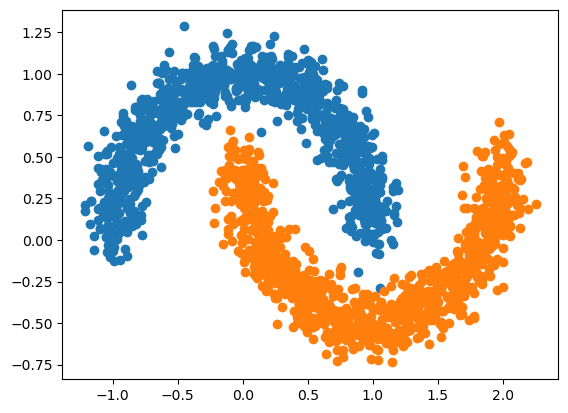

In [55]:
import matplotlib.pyplot as plt
plt.scatter(df[df['label']==0][0], df[df['label']==0][1])
plt.scatter(df[df['label']==1][0], df[df['label']==1][1])

In [57]:
from sklearn.cluster import KMeans

In [59]:
model=KMeans(n_clusters=2)

X=df[[0,1]]
model.fit(X)

KMeans(n_clusters=2)

In [61]:
df['prediction']=model.predict(X)

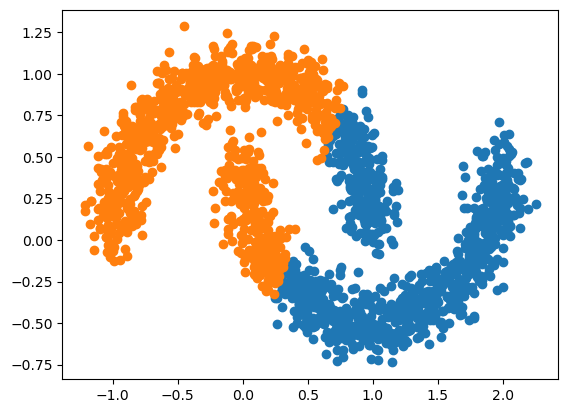

In [63]:
plt.scatter(df[df['prediction']==0][0], df[df['prediction']==0][1])
plt.scatter(df[df['prediction']==1][0], df[df['prediction']==1][1])

In [65]:
from sklearn.cluster import DBSCAN

In [77]:
model_dbscan = DBSCAN(eps=0.1)

In [79]:
df['DBSCAN'] = model_dbscan.fit_predict(X)

In [81]:
df

,0,1,label,prediction,DBSCAN
0,1.776507,0.192752,1,0,0
1,0.397809,0.930390,0,1,1
2,0.495308,-0.318321,1,0,0
3,-0.948944,0.163020,0,1,1
4,0.484957,-0.338160,1,0,0
...,...,...,...,...,...
1995,0.153343,0.104423,1,1,0
1996,0.383957,-0.340741,1,0,0
1997,-0.936494,0.528022,0,1,1
1998,0.839458,-0.626007,1,0,0


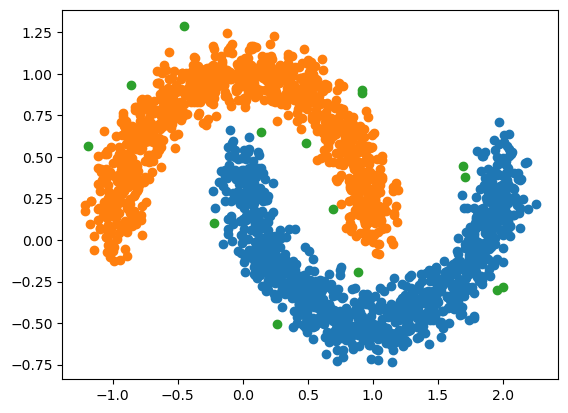

In [86]:
plt.scatter(df[df['DBSCAN']==0][0], df[df['DBSCAN']==0][1])
plt.scatter(df[df['DBSCAN']==1][0], df[df['DBSCAN']==1][1])
plt.scatter(df[df['DBSCAN']==-1][0], df[df['DBSCAN']==-1][1])

In [90]:
from sklearn.linear_model import LogisticRegression

model2= LogisticRegression()
model2.fit(X, y)
df['LogPrediction']=model2.predict(X)

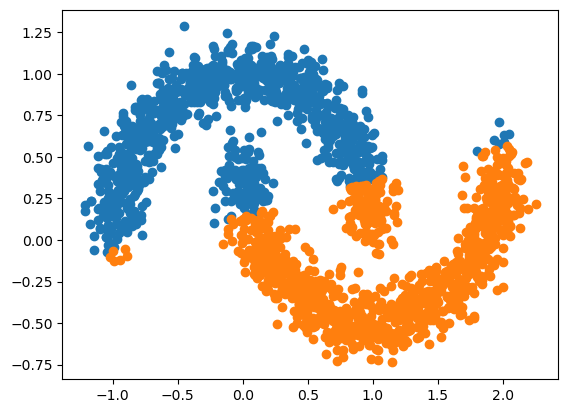

In [92]:
plt.scatter(df[df['LogPrediction']==0][0], df[df['LogPrediction']==0][1])
plt.scatter(df[df['LogPrediction']==1][0], df[df['LogPrediction']==1][1])
plt.scatter(df[df['LogPrediction']==-1][0], df[df['LogPrediction']==-1][1])

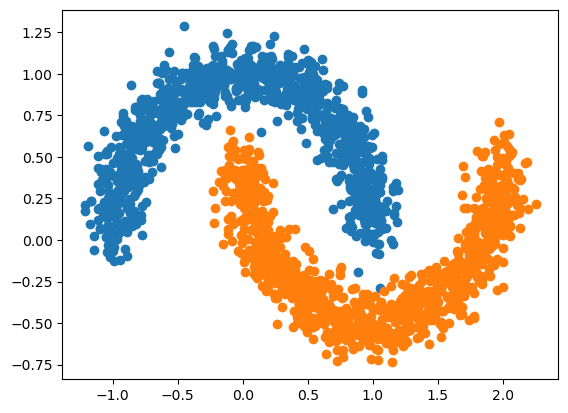

In [94]:
from sklearn.tree import DecisionTreeClassifier

model_df = DecisionTreeClassifier()
model_df.fit(X,y)

df['dt_prediction'] = model_df.predict(X)

plt.scatter(df[df['dt_prediction']==0][0], df[df['dt_prediction']==0][1])
plt.scatter(df[df['dt_prediction']==1][0], df[df['dt_prediction']==1][1])
plt.scatter(df[df['dt_prediction']==-1][0], df[df['dt_prediction']==-1][1])

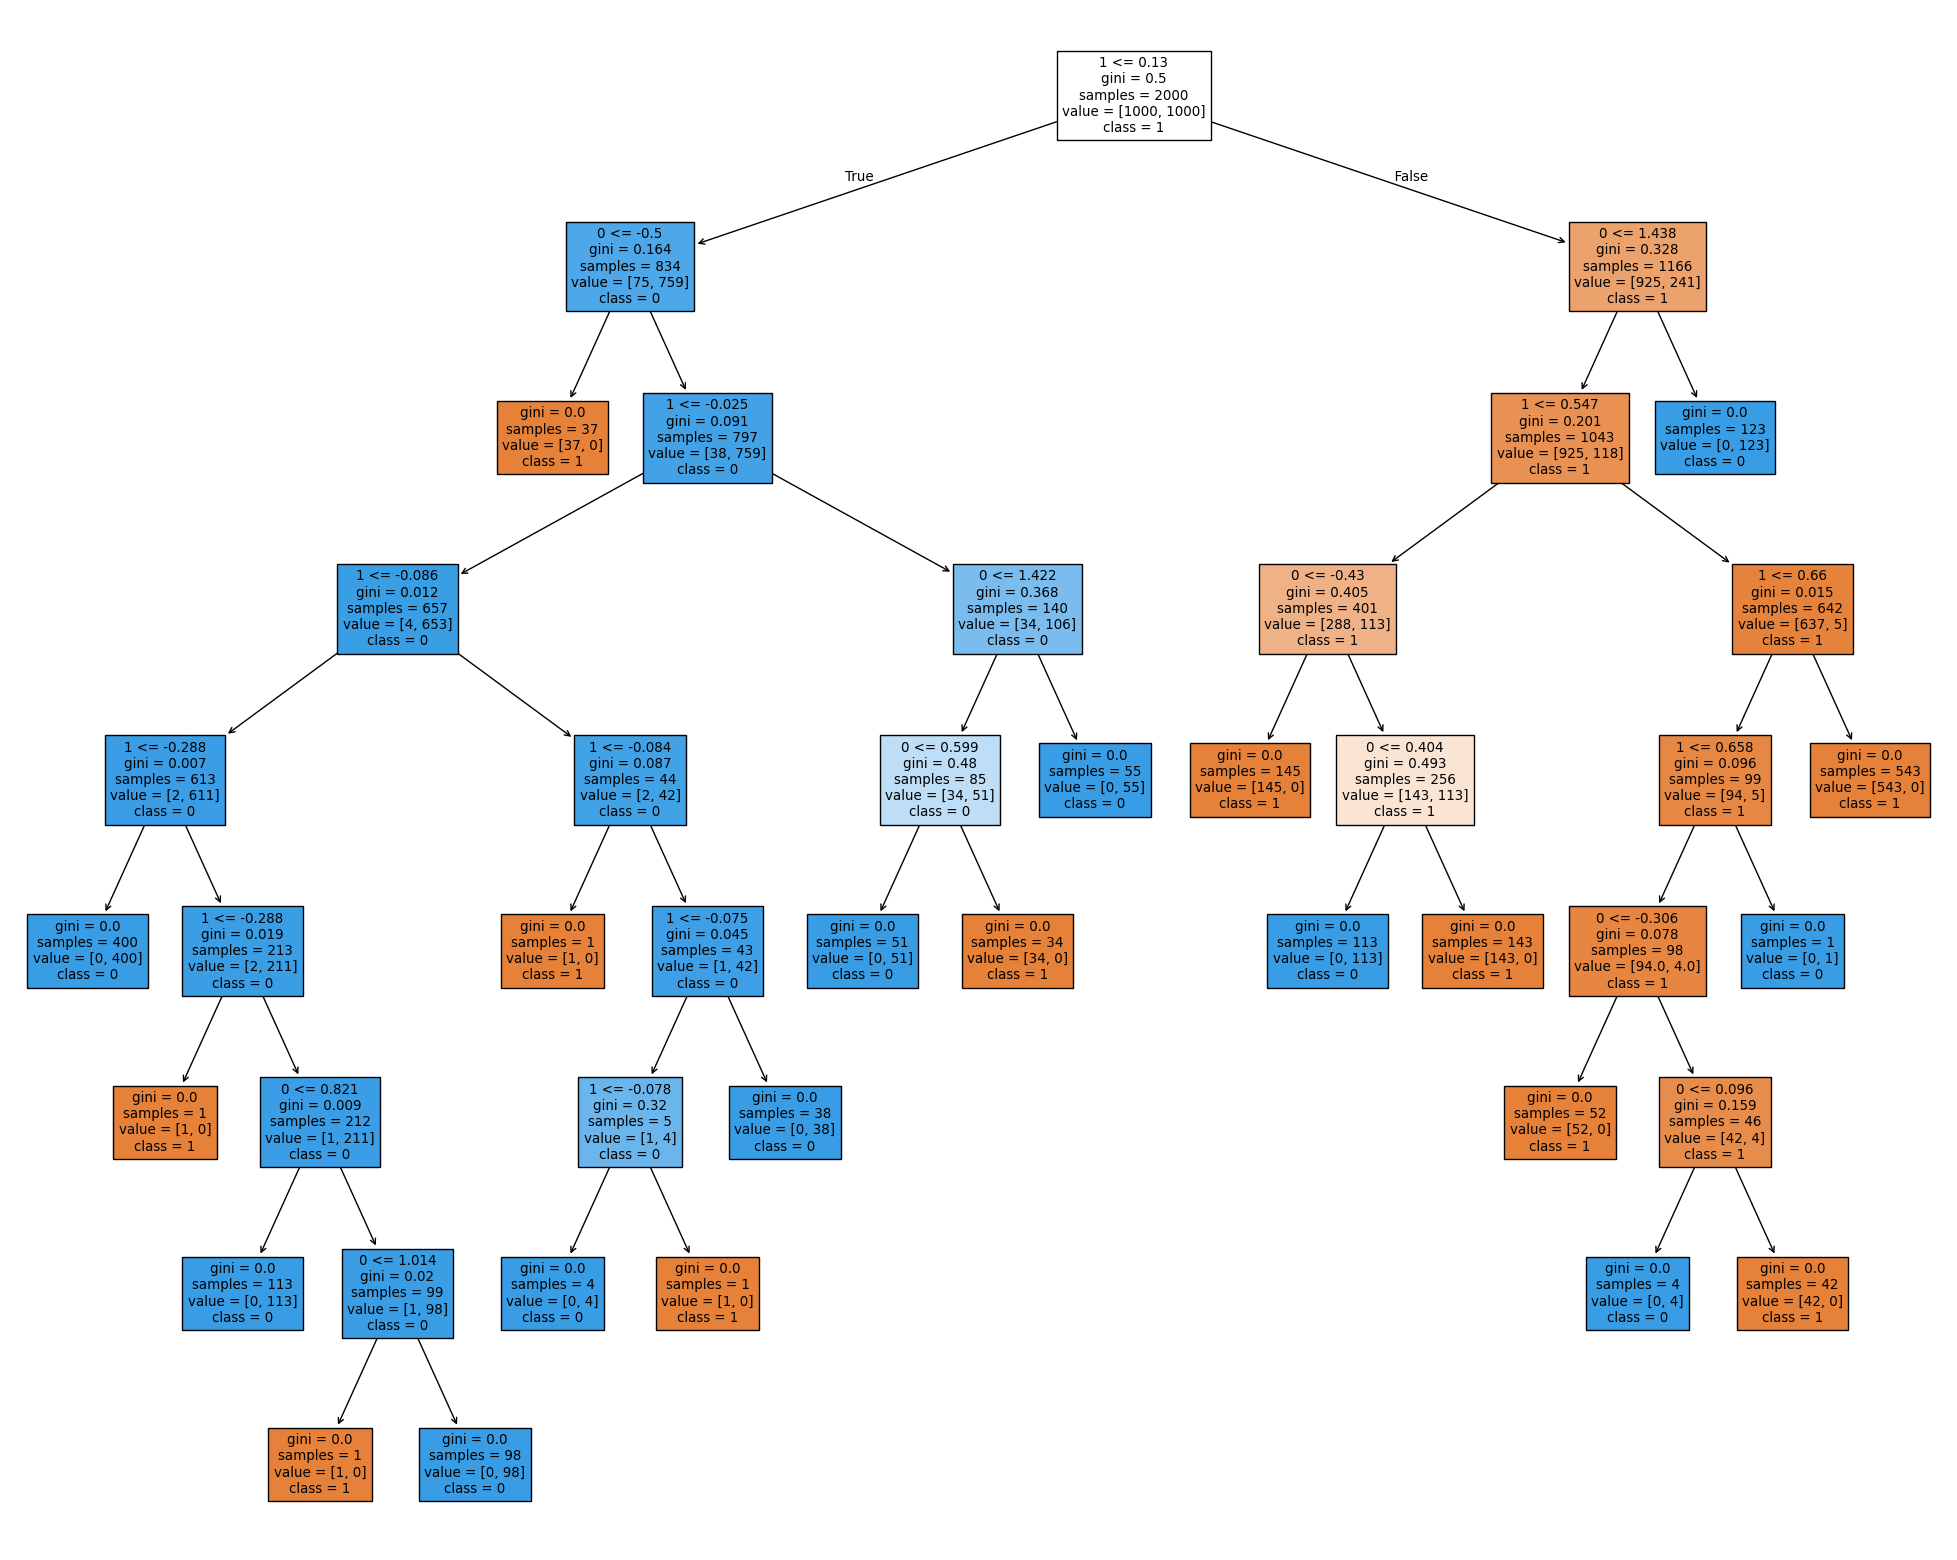

In [96]:
from sklearn import tree

fig=plt.figure(figsize=(25, 20))
_=tree.plot_tree(model_df,
                feature_names=X.columns,
                class_names=[str(i) for i in df['label'].unique()],
                filled=True)